# 🐧🐧Tarea 2 --- IELE756 🐧🐧
**Equipo Pinguino conformado por** : Hellen Quiñones, Gustavo Sánchez

**Comunas Asignadas**: Alhue, La Pintana, Huechuraba, El Monte, María Pinto

**Fecha de entrega**: jueves 16 de abril de 2026

**Link al repositorio de GitHub**: https://github.com/hellenelizabethqm-netizen/iele756-region-XXXX

---

**Objetivo**

Construir un perfil de salud de las comunas que te fueron asignadas utilizando dos conjuntos de datos complementarios: ENO (vigilancia de enfermedades de notificación obligatoria, 2007–2024) y GRD (registros de egresos hospitalarios, 2022–2024). En la Tarea 0 demostraste que podías abrir e inspeccionar cada conjunto de datos; en la Tarea 1 construiste una línea base demográfica a partir del Censo. Ahora profundizarás en los datos de salud: limpiando variables categóricas desordenadas, calculando tasas, construyendo perfiles de enfermedades por nacionalidad y produciendo tablas resumen a nivel comunal que luego unirás con el resumen censal en la Tarea 3.

---

#### Cargamos las Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

---

### **Parte A: ENO – Enfermedades de Notificación Obligatoria (5 pts)**
### **🐧🐧A.0 Carga y limpieza de datos (1 pt) 🐧🐧**
Primero escogemos las columnas relevantes para esta tarea, con un total de 11 columnas y 333300 filas.


In [2]:
############################################################
### 🐧🐧**A.0.1 Cargar el conjunto de datos ENO**🐧🐧 ####
############################################################

# escoger solo las columnas relevantes para el análisis

eno_cols = ["ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
            "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
            "cie_10_diagnostico", "diagnostico", "pais_contagio"]

# cargar el conjunto de datos ENO con las columnas seleccionadas
eno = pd.read_csv("20241218_base_eno_final.csv",
                  sep=";", encoding="utf-8-sig", usecols=eno_cols)

print(eno.shape)
eno.info()


(333300, 11)
<class 'pandas.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   region                    333300 non-null  str  
 1   nacionalidad              333300 non-null  str  
 2   cie_10_diagnostico        333300 non-null  str  
 3   diagnostico               333300 non-null  str  
 4   anho_notificacion         333300 non-null  int64
 5   ENO                       333300 non-null  str  
 6   nombre_instruccion        333300 non-null  str  
 7   pais_contagio             333300 non-null  str  
 8   sexo                      333300 non-null  str  
 9   grupo_edad                333300 non-null  str  
 10  codigo_comuna_residencia  333300 non-null  str  
dtypes: int64(1), str(10)
memory usage: 65.4 MB


In [3]:
eno.head()

,region,nacionalidad,cie_10_diagnostico,diagnostico,anho_notificacion,ENO,nombre_instruccion,pais_contagio,sexo,grupo_edad,codigo_comuna_residencia
0,Región de Tarapacá,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,25-29,01107
1,Región de Valparaíso,Desconocido,A90.X,FIEBRE DEL DENGUE,2018,Arbovirus,Desconocido,Desconocido,hombre,70-74,05301
2,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2020,Arbovirus,Desconocido,Desconocido,mujer,70-74,05109
3,Región de Valparaíso,Extranjero,A97.0,DENGUE SIN DATOS DE ALARMA,2019,Arbovirus,Desconocido,Desconocido,hombre,40-44,05301
4,Región de Valparaíso,Chile,A97.0,DENGUE SIN DATOS DE ALARMA,2021,Arbovirus,Desconocido,Desconocido,hombre,60-64,05109


---
Luego, filtramos por las columnas correspondientes a nuestras comunas a trabajar, en este caso, los códigos son:

	- 13107	Huechuraba
	- 13112	La Pintana
	- 13502	Alhué
	- 13504	María Pinto
	- 13602	El Monte

In [4]:
############################################################
### 🐧🐧**A.0.2 Filtrar a nuestra columnas**🐧🐧 ####
############################################################

MY_COMUNAS = [13107, 13112, 13502, 13504, 13602]

#esto se debe pasar a string, porque si no, se considera texto el MY_COMUNAS
my_comunas_str = [str(c) for c in MY_COMUNAS]

#luego debemos filtra eno con nuestras comunas
#el isin() es para filtrar solo las filas que tienen el codigo_comuna_residencia en nuestra lista de comunas
eno_com = eno[eno['codigo_comuna_residencia'].isin(my_comunas_str)].copy()

print(f"Filas en mis comunas: {len(eno_com)}")

Filas en mis comunas: 2545


Teniendo en cuenta las 2545 que representan nuestras comunas, ahora veremos cúantas filas se encuentran anonimizadas del dataset completo, es decir que no tienen un código de comuna si no que "*****"

In [5]:
anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
total_count = len(eno)
anon_pct = anon_count / total_count * 100

print(f"Filas anonimizadas '*****') en ENO completo: {anon_count}")
print(f"Porcentaje anonimizadas: {anon_pct:.2f}%")

Filas anonimizadas '*****') en ENO completo: 148217
Porcentaje anonimizadas: 44.47%


Lo anterior, muestra que 148.217, aproximadamente un 44.47%, de registros del dataset ENO tienen el valor anonimizado `"*****"` en la variable `codigo_comuna_residencia`.

 Esto constituye una limitación importante del conjunto de datos, ya que dichos registros no pueden asignarse a una comuna específica lo que trae como consecuencia que tanto los conteos, como el análisis a realizar para las comunas seleccionadas deben ser  interpretado como una subestimación de la verdadera carga de notificaciones.


---



In [6]:
############################################################
### 🐧🐧**A.0.3 Limpiar la variable de nacionalidad**🐧🐧 ####
############################################################

eno_com["nacionalidad"].value_counts(dropna=False)

nacionalidad
Chile          1342
Desconocido    1002
Extranjero      201
Name: count, dtype: int64

In [7]:
#se filtra el dataset para quedarnos solo con las filas que tienen nacionalidad Chile o Extranjero
eno_com_ce = eno_com.copy()
eno_com_ce = eno_com_ce[eno_com_ce["nacionalidad"].isin(["Chile", "Extranjero"])]

Los registros con nacionalidad "Desconocido" representan en total 1002 filas. Esto representa una fracción relevante de los datos, por lo que debrá tenerse en cuenta  para la interpretación. Sin embargo, para análisis específicos por nacionalidad, se excluirá  esta categoría.

Por otro lado, la nacionalidad chilena obtiene 1342 casos de ENO mientras que los extranjeros 201. Con ello, para este trabajo existen usualmente dos opciones a trabajar:

- `eno_com` --> Dataset con las comunas filtradas, CON la variable "Desconocido" para nacionalidad.

- `eno_com_ce` --> Dataset con las comunas filtradas, SIN la variable "Desconocido" para nacionalidad, solo "Chileno" y "Extranjero".
  
  
---


In [8]:
############################################################
### 🐧🐧**A.0.4 Reportar el período temporal*¨*🐧🐧 ####
############################################################

#valores mínimo y máximo de la variable anho_notificacion (año de notificación)
#se usa eno_com con desconocidos

eno_com["anho_notificacion"].min(), eno_com["anho_notificacion"].max()

notif_por_anho = (
    eno_com["anho_notificacion"]
    .value_counts() 
    .sort_index() #mayor a menor
    .reset_index()
)

notif_por_anho.columns = ["anho_notificacion", "n_notificaciones"] # renombrar columnas
notif_por_anho

,anho_notificacion,n_notificaciones
0,2007,118
1,2008,98
2,2009,108
3,2010,89
4,2011,116
5,2012,143
6,2013,123
7,2014,113
8,2015,124
9,2016,84


---

### **🐧🐧A.1 Tendencias de notificación en el tiempo (1 pt) 🐧🐧**

<Figure size 640x480 with 0 Axes>

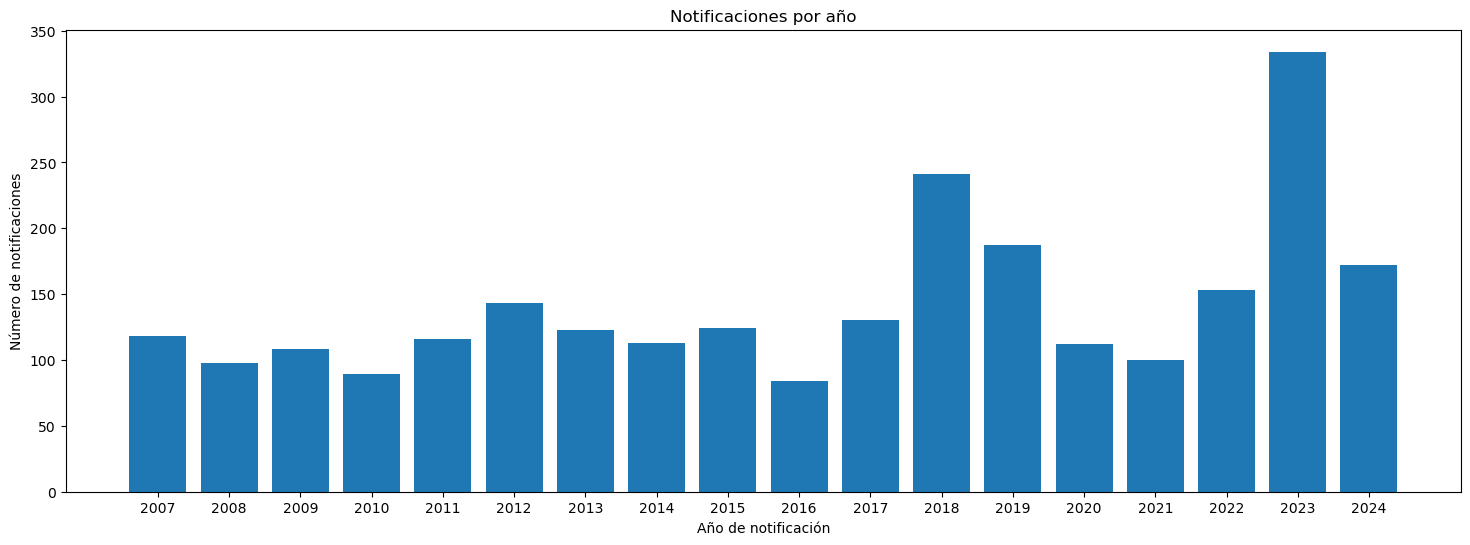

In [9]:
############################################################
### 🐧🐧**A.1.1 Tendencia general*¨*🐧🐧 ####
############################################################
#Se debe graficar el número total de notificaciones por año 
#se usa eno_com con desconocidos

plt.figure()

plt.figure(figsize=(18, 6))  # (ancho, alto)
plt.bar(
    notif_por_anho["anho_notificacion"],
    notif_por_anho["n_notificaciones"]
)

plt.xlabel("Año de notificación")
plt.xticks(
    ticks=notif_por_anho["anho_notificacion"],
    labels=notif_por_anho["anho_notificacion"].astype(int)
)
plt.ylabel("Número de notificaciones")
plt.title("Notificaciones por año")

plt.show()

El rango de datos se muestra entre 2007 y 2024, donde las notificaciones muestran variaciones moderadas.A partir de 2017 se observa un aumento que alcanza un máximo en 2023 reflejando un crecimiento reciente  
Aunque hay descensos intermedios la tendencia general es creciente en el largo plazo.

Estos cambios podrían asociarse tanto a  mejoras en el registro como a un incremento real de los eventos reportados, teniendo en cuenta que los años de pandemia entre 2021 y 2022.

Además, para obtener una vista un poco más interesante, a continuación se presenta el mismo gráfico separado por el top 5 de ENOS (dejando el resto de las variables en categorías de "otros") en donde se puede observar que el VIH, la Parotiditis y el Coqueluche predominan con el paso del tiempo hasta llegar al 2023, en donde la Sifilis hace más presencia hasta el 2024.

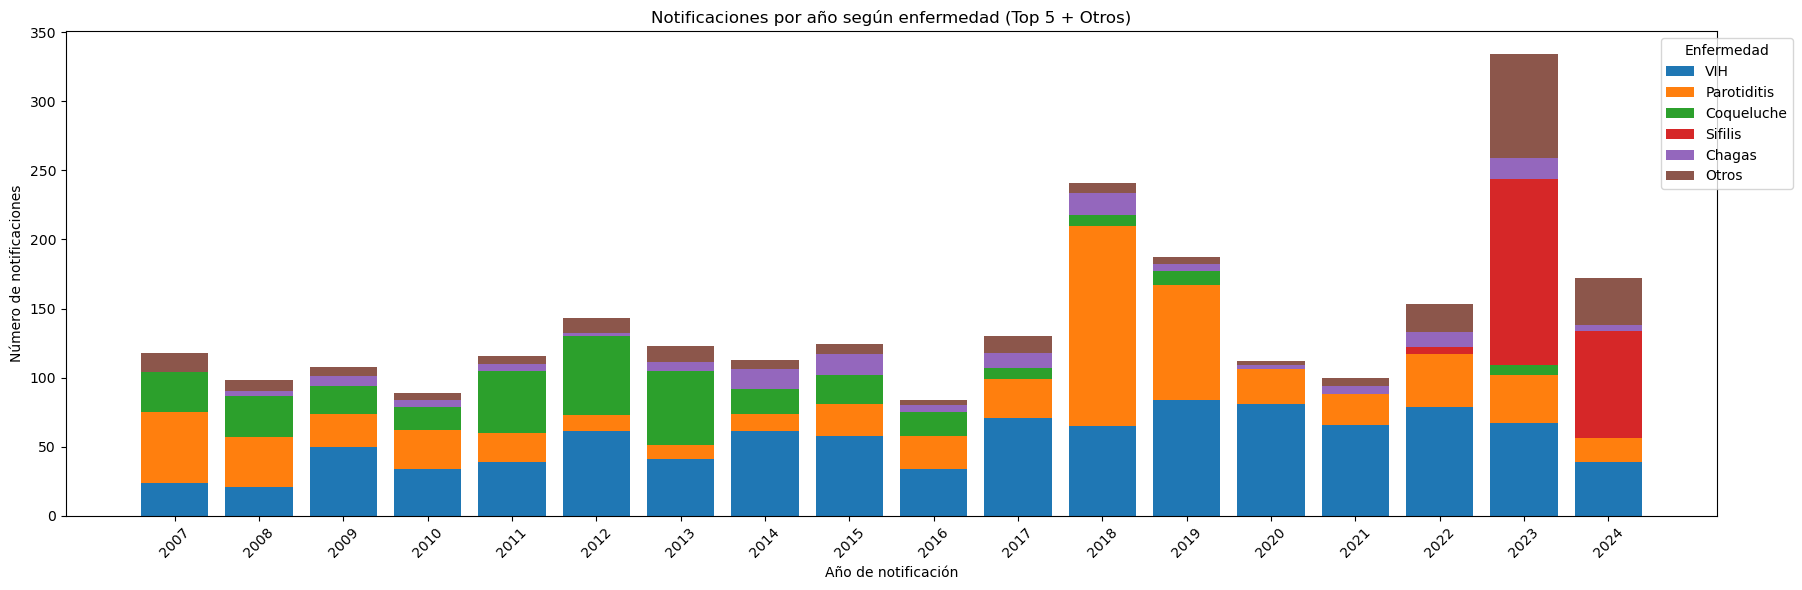

In [10]:
top_5_enos = eno_com["ENO"].value_counts().head(5).index

eno_com["ENO_top5"] = eno_com["ENO"].where(eno_com["ENO"].isin(top_5_enos), "Otros")

tabla_stack = (
    eno_com.groupby(["anho_notificacion", "ENO_top5"])
    .size()
    .unstack(fill_value=0)
    
)

orden_cols = [eno for eno in top_5_enos if eno in tabla_stack.columns]
if "Otros" in tabla_stack.columns:
    orden_cols = orden_cols + ["Otros"]

tabla_stack = tabla_stack[orden_cols]

plt.figure(figsize=(18, 6))

bottom = None

for eno in tabla_stack.columns:
    if bottom is None:
        plt.bar(tabla_stack.index, tabla_stack[eno], label=eno)
        bottom = tabla_stack[eno]
    else:
        plt.bar(tabla_stack.index, tabla_stack[eno], bottom=bottom, label=eno)
        bottom = bottom + tabla_stack[eno]

plt.xlabel("Año de notificación")
plt.ylabel("Número de notificaciones")
plt.title("Notificaciones por año según enfermedad (Top 5 + Otros)")
plt.xticks(tabla_stack.index, rotation=45)
plt.legend(title="Enfermedad", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()


---

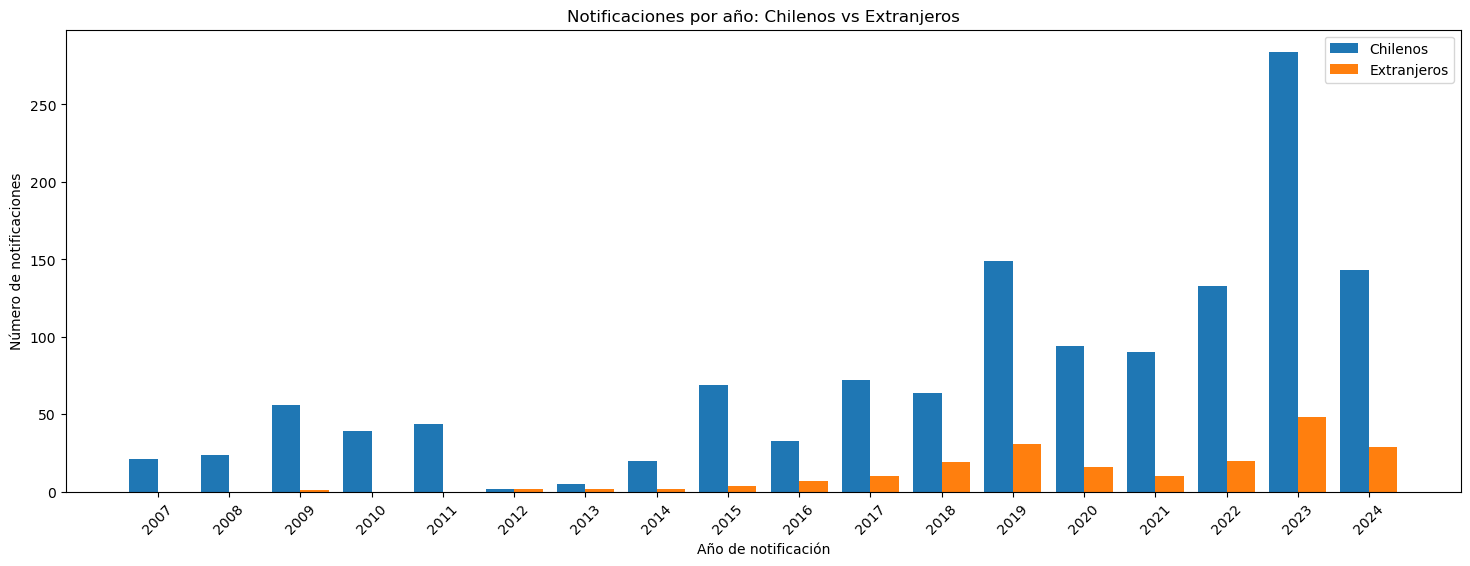

In [11]:

############################################################
### 🐧🐧**A.1.2 Tendencia por nacionalidad*¨*🐧🐧 ####
############################################################
#Se debe graficar el número total de notificaciones por año 
#se usa eno_com_ce SIN desconocidos


# Agrupar por año y nacionalidad
agrupado = (
    eno_com_ce.groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)


plt.figure(figsize=(18, 6))

x = agrupado.index

plt.bar(x - 0.2, agrupado["Chile"], width=0.4, label="Chilenos")
plt.bar(x + 0.2, agrupado["Extranjero"], width=0.4, label="Extranjeros")

plt.xlabel("Año de notificación")
plt.ylabel("Número de notificaciones")
plt.title("Notificaciones por año: Chilenos vs Extranjeros")

plt.legend()
plt.xticks(x, x.astype(int), rotation=45)

plt.show()

En el gráfico se observa un de notificaciones en población chilena a lo largo de todo el rango de años aunque con una tendencia a aumentar en personas extranjeras desde el año 2016 con leves bajas entre años, observando además el máximo de notificaciones en el año 2023 lo cual puede estar relacionado con el término de pandemia.

Con ello el aumento en ambos grupos en los últimos años sugiere una expansión general del fenómeno más que un cambio aislado en una sola población  

---
### **🐧🐧A.2 Perfiles de enfermedades (1.5 pts) 🐧🐧**


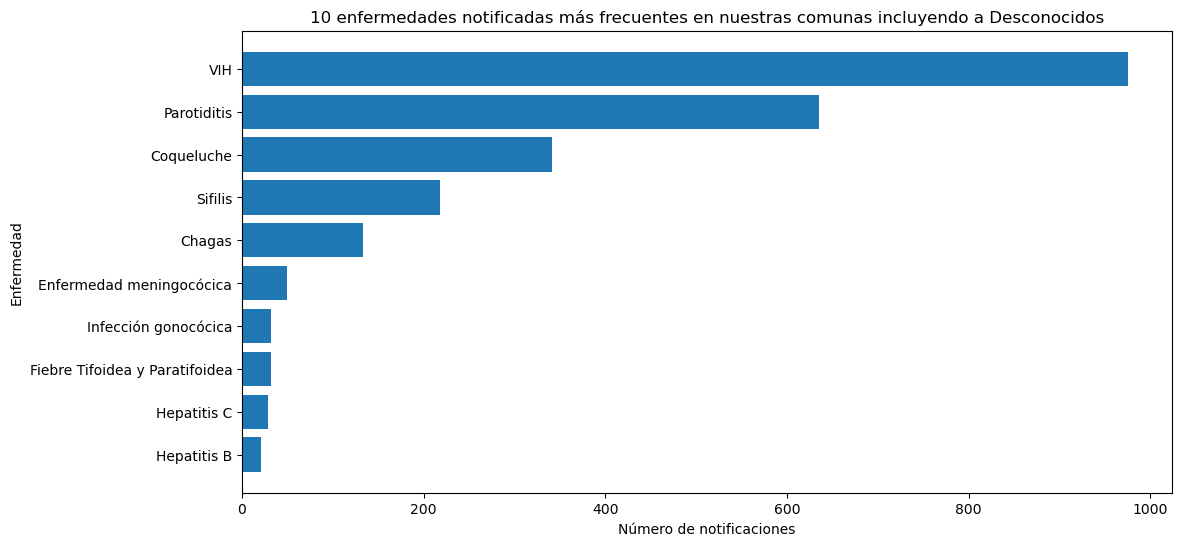

In [12]:
############################################################
### 🐧🐧**A.2.1 Principales enfermedades en general*¨*🐧🐧 ####
############################################################

#Muestra las 10 enfermedades notificadas más frecuentes...
# en tus comunas considerando todos los años. Preséntalo como un gráfico de barras horizontal.
##se usa eno_com CON desconocidos

top_10_eno = (
    eno_com["ENO"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12, 6))
plt.barh(top_10_eno.index, top_10_eno.values)

plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")
plt.title("10 enfermedades notificadas más frecuentes en nuestras comunas incluyendo a Desconocidos")

plt.show()



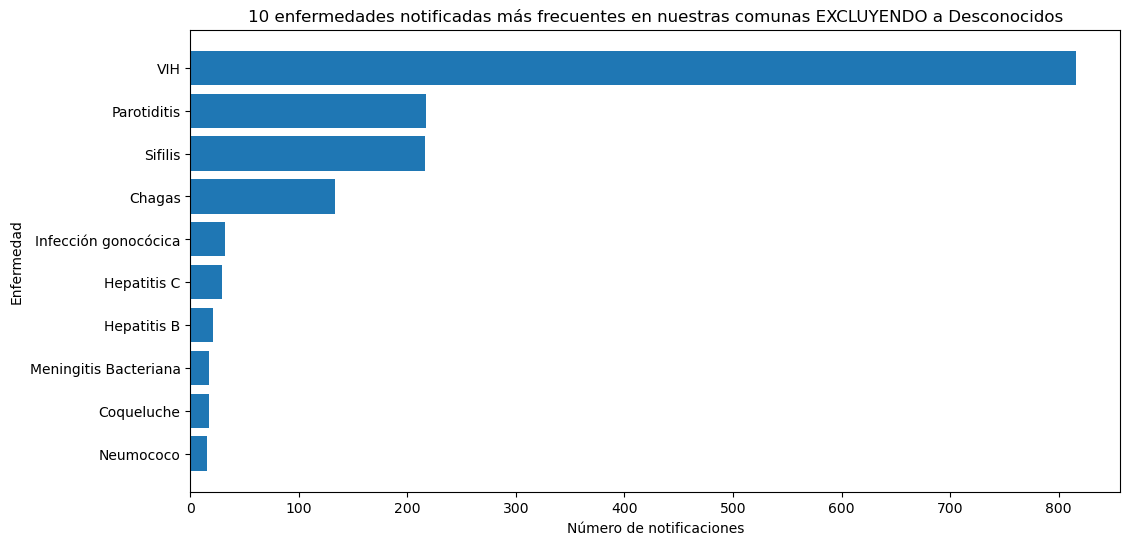

In [13]:
#se usa eno_com_ce SIN desconocidos

top_10_eno = (
    eno_com_ce["ENO"]
    .value_counts()
    .head(10)
    .sort_values()
)

plt.figure(figsize=(12, 6))
plt.barh(top_10_eno.index, top_10_eno.values)

plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad")
plt.title("10 enfermedades notificadas más frecuentes en nuestras comunas EXCLUYENDO a Desconocidos")

plt.show()


---

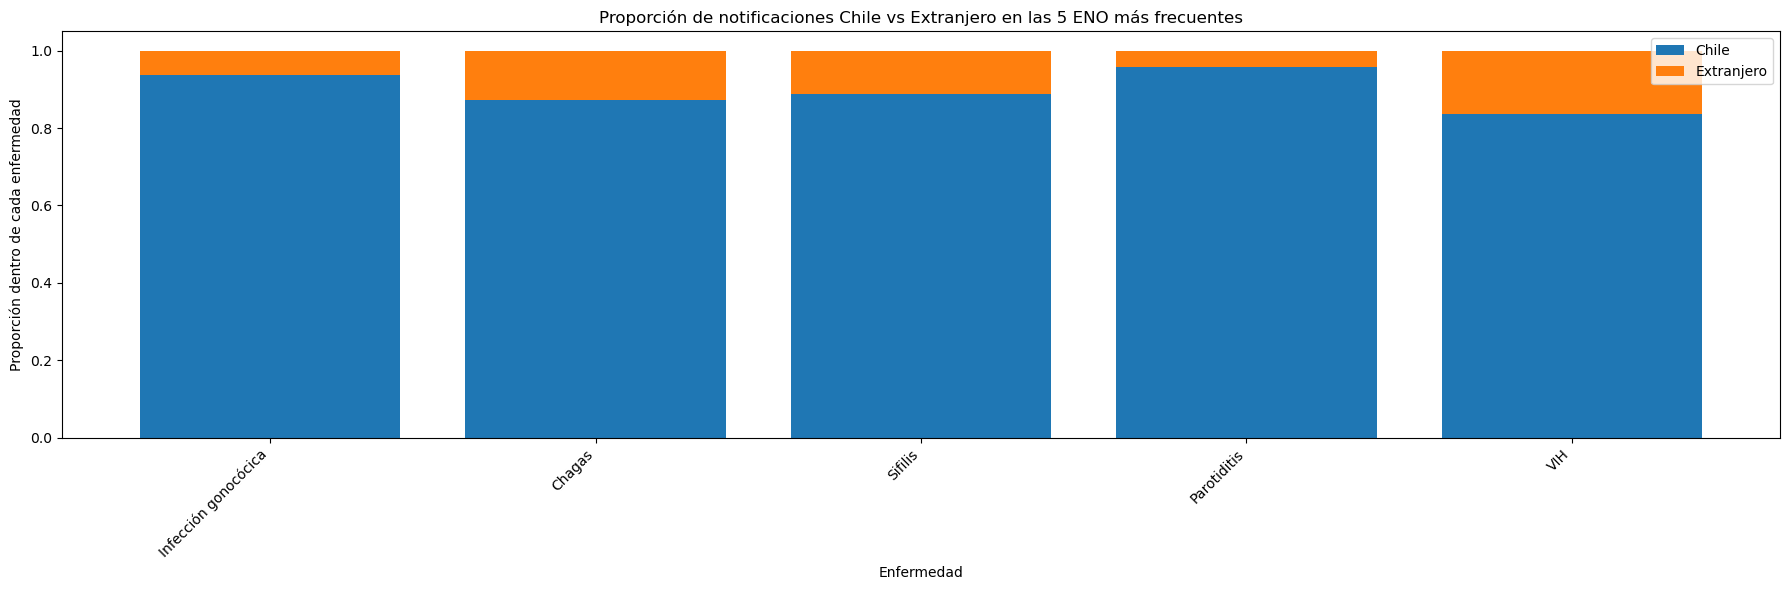

In [14]:

############################################################
### 🐧🐧**A.2.2 Perfiles de enfermedades por nacionalidad*¨*🐧🐧 ####
############################################################

#Para cada una de las 5 enfermedades más frecuentes, calcula la proporción de notificaciones chilenas vs. extranjeras...
# ...excluyendo "Desconocido"). Preséntalo como un gráfico de barras agrupadas o apiladas.

#se usa eno_com_ce SIN desconocidos


top_5_eno = (
    eno_com_ce["ENO"]
    .dropna()
    .value_counts()
    .head(5)
    .index
)

df_top5 = eno_com_ce[eno_com_ce["ENO"].isin(top_5_eno)]

tabla = (
    df_top5.groupby(["ENO", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

prop_tabla = tabla.div(tabla.sum(axis=1), axis=0)
prop_tabla = prop_tabla.loc[tabla.sum(axis=1).sort_values().index]

plt.figure(figsize=(18, 6))

x = range(len(prop_tabla))

# Chile abajo
plt.bar(x, prop_tabla["Chile"], label="Chile")

# Extranjero arriba (apilado sobre Chile)
plt.bar(x, prop_tabla["Extranjero"], 
        bottom=prop_tabla["Chile"], 
        label="Extranjero")

plt.xticks(x, prop_tabla.index, rotation=45, ha="right")
plt.ylabel("Proporción dentro de cada enfermedad")
plt.xlabel("Enfermedad")
plt.title("Proporción de notificaciones Chile vs Extranjero en las 5 ENO más frecuentes")
plt.legend()
plt.tight_layout()
plt.show()


El gráfico anterior muestra que la proporción de notificaciones en chilenos es mayor que la de extranjeros, teniendo una  mayor proporción de Parotiditis. En extranjeros, estas proporciones varía entre enfermedades, siendo mayor en VIH y Chagas y menor en parotiditis e infección gonocócica. Sin embargo, para poder analizar de mejor manera sobre esto, necesitamos considerar la población de las comunas, de forma de normalizar estos datos.

Con ayuda de los resultados de la tarea 1, se generó un nuevo gráfico el cúal muestra los datos normalizados con una tasa de notificación por cada 100.000 habitantes, de forma de corregir las diferencias en el tamaño poblacional entre ambos grupos.Siguiendo la fórmula:

Tasa de notificación por 100.000 habitantes=
número de notificaciones\población del grupo* 100000

La lógica es primero dividir el número de notificaciones por la cantidad de habitantes del grupo correspondiente, para obtener la frecuencia relativa de casos, y luego multiplicar por 100.000 para expresar esa frecuencia en una escala más interpretable. De este modo, el resultado indica cuántas notificaciones habría por cada 100.000 habitantes.

In [ ]:
#nos apoyamos de la tarea 1 para obtener la población total, chilena y extranjera por comuna
t1 = pd.read_csv("output_tarea1_comuna_summary.csv")
t1.head()



,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,13107,Huechuraba,101808,92790,8381,8.28,36.0,35.0,12.77,14.12,63.92,75.80,0.44
1,13112,La Pintana,175421,166483,7732,4.44,34.0,32.0,10.01,11.47,55.71,67.68,0.49
2,13502,Alhué,7768,6871,879,11.34,37.0,28.0,10.60,11.38,63.78,77.52,0.51
3,13504,María Pinto,15352,14996,319,2.08,38.0,31.0,10.60,11.46,61.08,69.20,0.52
4,13602,El Monte,37497,36404,915,2.45,36.0,34.0,10.90,12.53,60.75,69.14,0.50


In [16]:
#obtenemos el total de población chilena y extranjera sumando las comunas de nuestro análisis
pop_df = t1.copy()
pop_df[["nombre_comuna", "pop_total", "pop_chilean", "pop_foreign", "pct_foreign"]]

total_pop_chilean = pop_df["pop_chilean"].sum()
total_pop_foreign = pop_df["pop_foreign"].sum()

print(f"Población chilena total: {total_pop_chilean}")
print(f"Población extranjera total: {total_pop_foreign}")

Población chilena total: 317544
Población extranjera total: 18226


In [17]:
tabla_rates = tabla.copy()

#calculamos la tasa por cada 100.000 habitantes para chilenos y extranjeros
tabla_rates["tasa_chile_100k"] = tabla_rates.get("Chile") / total_pop_chilean * 100000
tabla_rates["tasa_extranjero_100k"] = tabla_rates.get("Extranjero") / total_pop_foreign * 100000

tabla_rates = tabla_rates[["tasa_chile_100k", "tasa_extranjero_100k"]]
tabla_rates = tabla_rates.sort_values("tasa_chile_100k")

tabla_rates

nacionalidad,tasa_chile_100k,tasa_extranjero_100k
ENO,,
Infección gonocócica,9.447510,10.973335
Chagas,36.530371,93.273346
Sifilis,60.464062,131.680018
Parotiditis,65.502733,49.380007
VIH,215.088303,729.726764


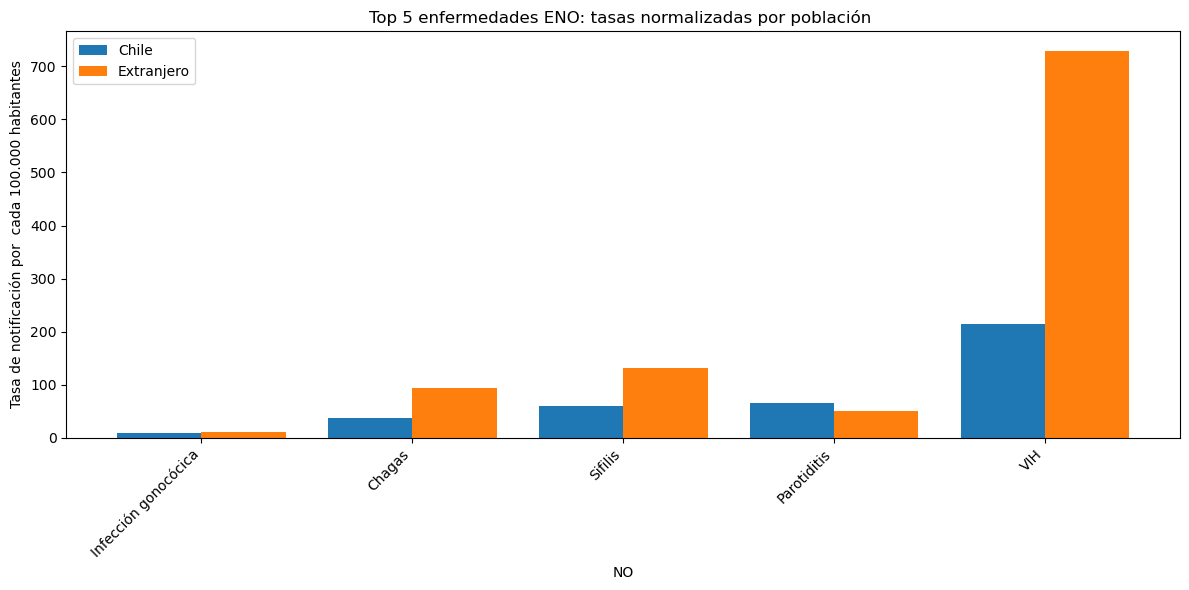

In [18]:
plt.figure(figsize=(12, 6))

x = range(len(tabla_rates))

plt.bar([i - 0.2 for i in x], tabla_rates["tasa_chile_100k"], width=0.4, label="Chile")
plt.bar([i + 0.2 for i in x], tabla_rates["tasa_extranjero_100k"], width=0.4, label="Extranjero")

plt.xticks(x, tabla_rates.index, rotation=45, ha="right")
plt.ylabel("Tasa de notificación por  cada 100.000 habitantes")
plt.xlabel("NO")
plt.title("Top 5 enfermedades ENO: tasas normalizadas por población ")
plt.legend()
plt.tight_layout()
plt.show()

Al normalizar, se observan diferencias importantes en la carga relativa de algunas enfermedades. En el caso del VIH, este presenta la mayor brecha entre ambos grupos, con una tasa más alta en población extranjera que en población chilena, caso que ocurre al igual que con las ENO: Chagas y Sífilis.

En cambio, Parotiditis muestra una tasa algo mayor en población chilena, y la Infección gonocócica presenta tasas bajas bastante cercanas entre ambos grupos. 

Finalmente, estos nuevos resultados sugieren que, al ajustar por tamaño poblacional, ciertas enfermedades están sobrerrepresentadas descriptivamente en la población extranjera de las comunas analizadas.

Sin embargo, como punto a tener en cuenta, estas tasas deben interpretarse con cuidado, ya que corresponden a una medida descriptiva cruda: el numerador agrega notificaciones de varios años, mientras que el denominador poblacional proviene del resumen demográfico de la Tarea 1.

---

In [19]:
############################################################
### 🐧🐧**A.2.3 Distribución por grupo etario para la enfermedad principal*¨*🐧🐧 ####
############################################################

#Escoge la enfermedad más común en tus comunas. 
#Grafica su distribución por grupo etario (grupo_edad), separada por nacionalidad. Comenta cualquier diferencia visible en el perfil etario.

#se usa eno_com_ce SIN desconocidos

#nos quedamos con el top 1 de ENO
top_1_ENO = eno_com_ce["ENO"].value_counts().idxmax()
print(f"La enfermedad más frecuente es: {top_1_ENO}")


La enfermedad más frecuente es: VIH


In [20]:
#filtramos la data solo para la enfermedad más frecuente, el VIH
df_top_1_ENO  = eno_com_ce[eno_com_ce ["ENO"] == top_1_ENO].copy()
print(f"Número de registros para {top_1_ENO}: {len(df_top_1_ENO)}")

Número de registros para VIH: 816


In [21]:
#vemos la distribución por grupo de edad de la tabla filtrada por VIH
df_top_1_ENO["grupo_edad"].value_counts()

grupo_edad
25-29    175
30-34    142
20-24    131
35-39    100
40-44     72
45-49     53
50-54     51
15-19     34
55-59     21
60-64     14
65-69      8
75-79      5
70-74      3
***        3
00-04      2
05-09      2
Name: count, dtype: int64

In [22]:
#se identificaron registros con grupo de edad "***", que no aportan información útil, por lo que se eliminan
df_top_1_ENO = df_top_1_ENO[df_top_1_ENO["grupo_edad"] != "***"]

In [23]:
tabla_edad = (
    df_top_1_ENO.groupby(["grupo_edad", "nacionalidad"])
    .size()
    .unstack(fill_value=0)
)

orden_edades = [
    "00-04", "05-09", "15-19", "20-24", "25-29",
    "30-34", "35-39", "40-44", "45-49",
    "50-54", "55-59", "60-64", "65-69",
    "70-74", "75-79"
]

tabla_edad = tabla_edad.reindex(orden_edades)
tabla_edad

nacionalidad,Chile,Extranjero
grupo_edad,,
00-04,1,1
05-09,2,0
15-19,32,2
20-24,114,17
25-29,141,34
30-34,113,29
35-39,80,20
40-44,54,18
45-49,45,8


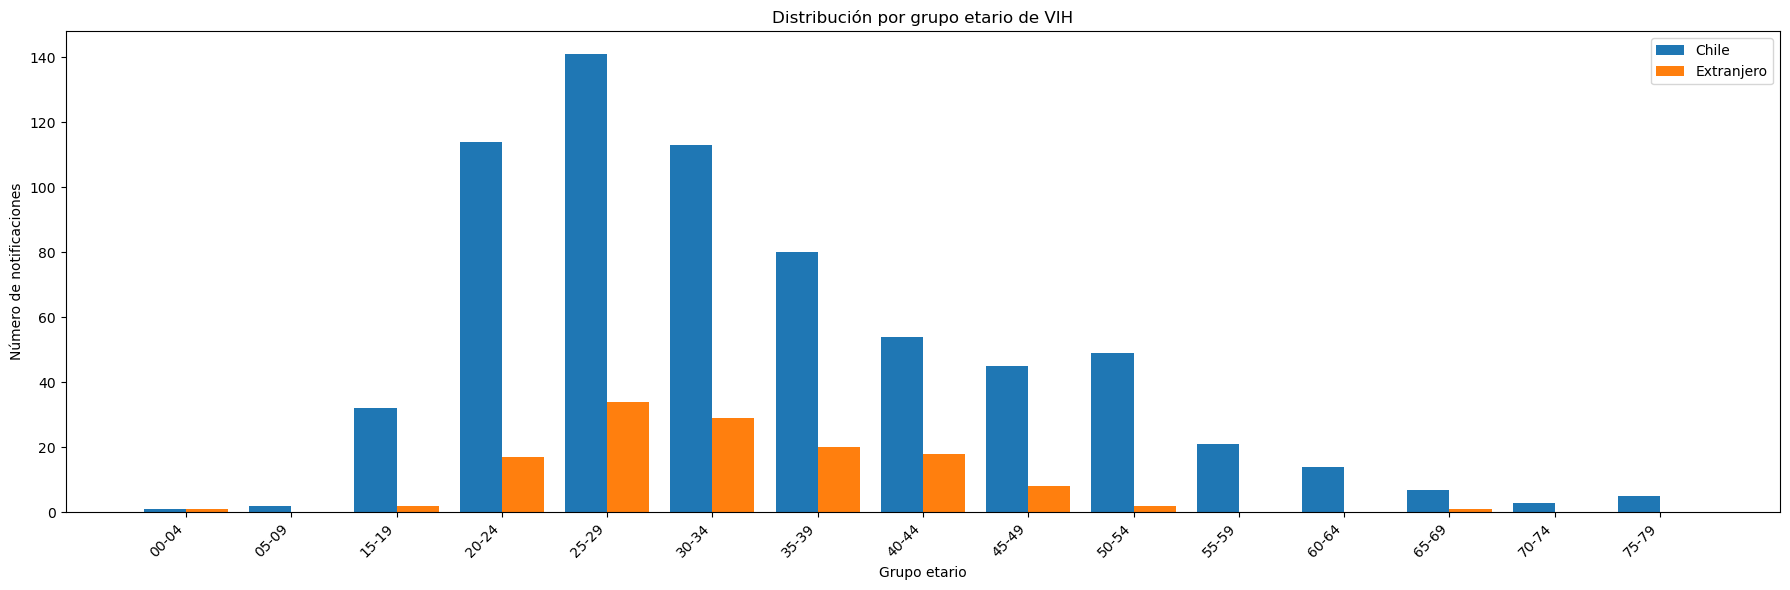

In [24]:
plt.figure(figsize=(18, 6))

x = range(len(tabla_edad))

plt.bar([i - 0.2 for i in x], tabla_edad.get("Chile", 0), width=0.4, label="Chile")
plt.bar([i + 0.2 for i in x], tabla_edad.get("Extranjero", 0), width=0.4, label="Extranjero")

plt.xticks(x, tabla_edad.index, rotation=45, ha="right")
plt.ylabel("Número de notificaciones")
plt.xlabel("Grupo etario")
plt.title(f"Distribución por grupo etario de {top_1_ENO}")
plt.legend()
plt.tight_layout()
plt.show()

En el gráfico anterior se observa la distribución por grupo etario del VIH, la enfermedad ENO más frecuente en las comunas analizadas. Se aprecia un patrón similar entre chilenos y extranjeros: las notificaciones aumentan hasta alcanzar su máximo en el grupo de 25 a 29 años y luego disminuyen progresivamente a medida que aumenta la edad.

---

### **🐧🐧A.3 Visión espacial (0.5 pts) 🐧🐧**

In [25]:
###############################################
### 🐧🐧 **A.3.1 Conteo de notificaciones por comuna** 🐧🐧 ####
###############################################

# Mapeo de códigos a nombres de comuna
comunas_dict = {
    "13107": "Huechuraba",
    "13112": "La Pintana",
    "13502": "Alhué",
    "13504": "María Pinto",
    "13602": "El Monte"
}

# 1) Conteo total de notificaciones ENO por comuna
eno_por_comuna = (
    eno_com.groupby("codigo_comuna_residencia")
    .size()
    .reset_index(name="eno_total")
)

eno_por_comuna["nombre_comuna"] = eno_por_comuna["codigo_comuna_residencia"].map(comunas_dict)

eno_por_comuna = eno_por_comuna[["codigo_comuna_residencia", "nombre_comuna", "eno_total"]]
eno_por_comuna = eno_por_comuna.sort_values("eno_total", ascending=False)

eno_por_comuna

,codigo_comuna_residencia,nombre_comuna,eno_total
1,13112,La Pintana,1507
0,13107,Huechuraba,832
4,13602,El Monte,146
3,13504,María Pinto,32
2,13502,Alhué,28


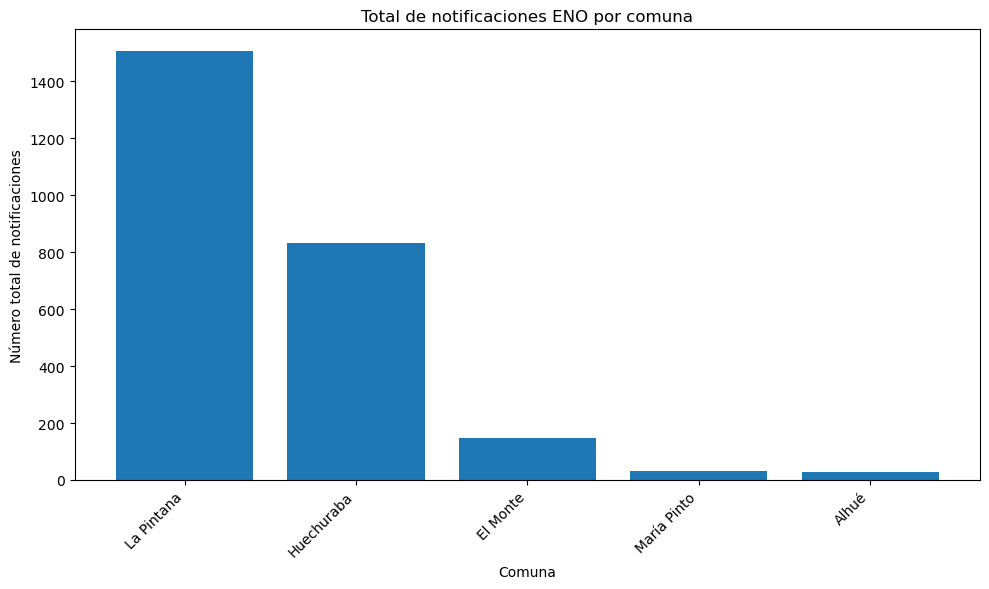

In [26]:
plt.figure(figsize=(10, 6))
plt.bar(eno_por_comuna["nombre_comuna"], eno_por_comuna["eno_total"])

plt.xlabel("Comuna")
plt.ylabel("Número total de notificaciones")
plt.title("Total de notificaciones ENO por comuna")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Podemos notar que en La Pintana existe un mayor número de notificaciones seguido de Huechuraba, esto tiene sentido producto de la cantidad de personas existentes en cada una de las comunas. Por lo que realizaremos una normalización.

In [ ]:
#se obtiene la población total por comuna desde la tarea 1, para demostrar lo anterior
t1_motrar= t1[["nombre_comuna", "pop_total"]]
t1_motrar

,nombre_comuna,pop_total
0,Huechuraba,101808
1,La Pintana,175421
2,Alhué,7768
3,María Pinto,15352
4,El Monte,37497


---

Con ello, a continuación realizaremos la normalización mencionada

In [ ]:
#  Unir con población total desde la tabla de Tarea 1
eno_comuna_rate = eno_por_comuna.merge(
    t1[["nombre_comuna", "pop_total"]],
    on="nombre_comuna",
    how="left"
)

# Calcular tasa cruda por 10.000 habitantes
eno_comuna_rate["eno_rate_per_10k"] = (
    eno_comuna_rate["eno_total"] / eno_comuna_rate["pop_total"] * 10000
)

eno_comuna_rate = eno_comuna_rate.sort_values("eno_rate_per_10k", ascending=False)

eno_comuna_rate

,codigo_comuna_residencia,nombre_comuna,eno_total,pop_total,eno_rate_per_10k
0,13112,La Pintana,1507,175421,85.907617
1,13107,Huechuraba,832,101808,81.722458
2,13602,El Monte,146,37497,38.936448
4,13502,Alhué,28,7768,36.045314
3,13504,María Pinto,32,15352,20.844190


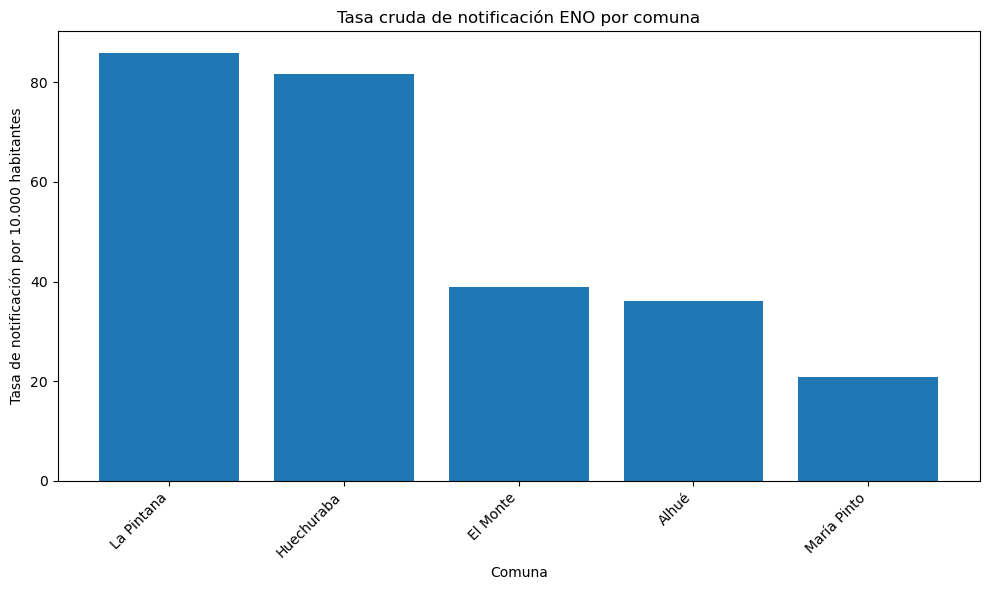

In [28]:
plt.figure(figsize=(10, 6))
plt.bar(eno_comuna_rate["nombre_comuna"], eno_comuna_rate["eno_rate_per_10k"])

plt.xlabel("Comuna")
plt.ylabel("Tasa de notificación por 10.000 habitantes")
plt.title("Tasa cruda de notificación ENO por comuna")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:

# Top 5 enfermedades ENO globales en mis comunas
top_5_enos = eno_com["ENO"].value_counts().head(5).index

# Crear categoría Top 5 + Otros
eno_com["ENO_top5"] = eno_com["ENO"].where(eno_com["ENO"].isin(top_5_enos), "Otros")

# Agrupar por comuna y tipo de ENO
eno_comuna_tipo = (
    eno_com.groupby(["codigo_comuna_residencia", "ENO_top5"])
    .size()
    .unstack(fill_value=0)
)

# Ordenar columnas: top 5 primero, Otros al final
orden_cols = [eno for eno in top_5_enos if eno in eno_comuna_tipo.columns]
if "Otros" in eno_comuna_tipo.columns:
    orden_cols = orden_cols + ["Otros"]

eno_comuna_tipo = eno_comuna_tipo[orden_cols]

# Agregar nombre de comuna
eno_comuna_tipo["nombre_comuna"] = eno_comuna_tipo.index.map(comunas_dict)

# Reordenar comunas por total de notificaciones
eno_comuna_tipo["total"] = eno_comuna_tipo[orden_cols].sum(axis=1)
eno_comuna_tipo = eno_comuna_tipo.sort_values("total", ascending=False)

eno_comuna_tipo

ENO_top5,VIH,Parotiditis,Coqueluche,Sifilis,Chagas,Otros,nombre_comuna,total
codigo_comuna_residencia,,,,,,,,
13112,583,335,259,121,77,132,La Pintana,1507
13107,291,270,73,74,33,91,Huechuraba,832
13602,82,17,7,14,10,16,El Monte,146
13504,12,7,0,4,5,4,María Pinto,32
13502,7,6,2,5,8,0,Alhué,28


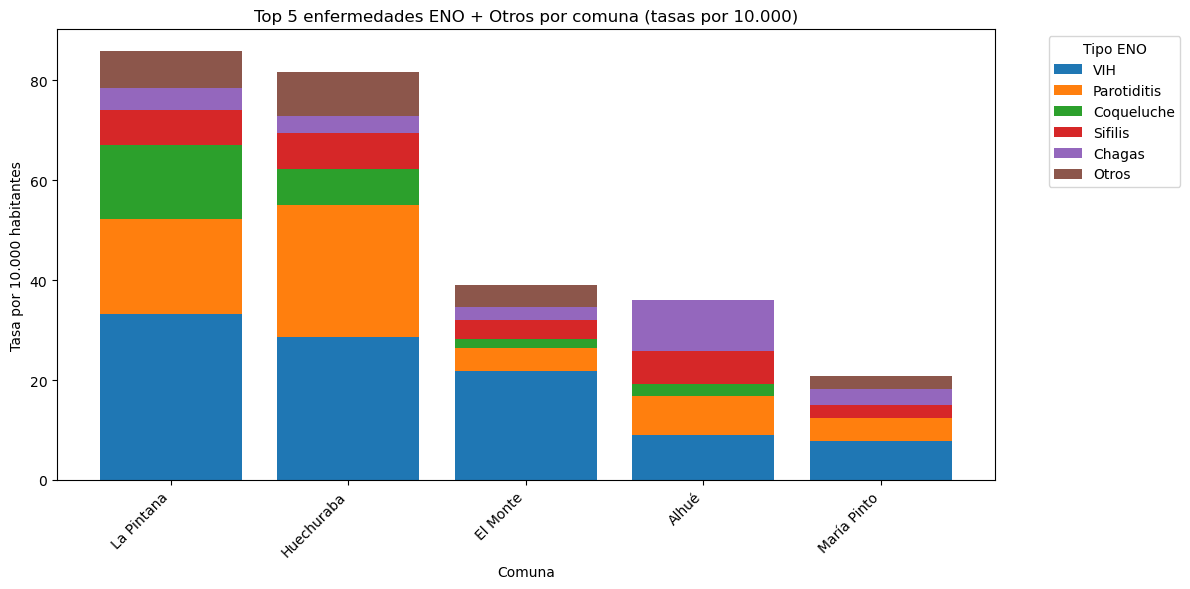

In [41]:



# Copia para no pisar la original
tasas_comuna_tipo = eno_comuna_tipo.copy()

eno_comuna_tipo = eno_comuna_tipo.merge(
    t1[["nombre_comuna", "pop_total"]],
    on="nombre_comuna",
    how="left"
)

# Calcular tasas por 10.000 para cada categoría ENO
for col in orden_cols:
    tasas_comuna_tipo[col] = tasas_comuna_tipo[col] / tasas_comuna_tipo["pop_total"] * 10000

# Ordenar por tasa total si quieres
tasas_comuna_tipo["tasa_total"] = tasas_comuna_tipo[orden_cols].sum(axis=1)
tasas_comuna_tipo = tasas_comuna_tipo.sort_values("tasa_total", ascending=False)

# Gráfico de barras apiladas
plt.figure(figsize=(12, 6))

bottom = [0] * len(tasas_comuna_tipo)

for col in orden_cols:
    plt.bar(
        tasas_comuna_tipo["nombre_comuna"],
        tasas_comuna_tipo[col],
        bottom=bottom,
        label=col
    )
    bottom = bottom + tasas_comuna_tipo[col].values

plt.xticks(rotation=45, ha="right")
plt.ylabel("Tasa por 10.000 habitantes")
plt.xlabel("Comuna")
plt.title("Top 5 enfermedades ENO + Otros por comuna (tasas por 10.000)")
plt.legend(title="Tipo ENO", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

En esta sección se calcularon los conteos totales de notificaciones ENO por comuna, agregando todos los años disponibles. Luego, utilizando la población total obtenida en la Tarea 1 (`pop_total`), se construyó una tasa cruda de notificación por 10.000 habitantes para comparar de forma más justa comunas con tamaños poblacionales distintos.

Es importante señalar que estos conteos comunales corresponden a una subestimación de la carga real de notificaciones, debido a que una fracción importante del dataset ENO presenta la comuna de residencia anonimizada como `"*****"`, por lo que esos registros no pueden ser asignados territorialmente.